In [ ]:
from __future__ import annotations
import ast
import pandas as pd

try:
    from News.EDA_clean.EDA_raw_news import add_description_word_count
    from News.EDA_clean.EDA_raw_news import build_year_before_2010_rows
    from News.EDA_clean.EDA_raw_news import INPUT_PATH
    from News.EDA_clean.EDA_raw_news import load_input_data
    from News.EDA_clean.EDA_raw_news import NULL_LIKE_VALUES
    from News.EDA_clean.EDA_raw_news import normalize_text_columns
    from News.EDA_clean.EDA_raw_news import parse_publication_date_series
    from News.EDA_clean.EDA_raw_news import TEXT_COLUMNS
except ImportError:
    from News.EDA_clean.EDA_raw_news import add_description_word_count
    from News.EDA_clean.EDA_raw_news import build_year_before_2010_rows
    from News.EDA_clean.EDA_raw_news import INPUT_PATH
    from News.EDA_clean.EDA_raw_news import load_input_data
    from News.EDA_clean.EDA_raw_news import NULL_LIKE_VALUES
    from News.EDA_clean.EDA_raw_news import normalize_text_columns
    from News.EDA_clean.EDA_raw_news import parse_publication_date_series
    from News.EDA_clean.EDA_raw_news import TEXT_COLUMNS


def normalize_domain_column(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = df.copy()
    normalize_domain = out.copy()
    domain = normalize_domain["domain"].astype("string").str.lower()
    domain = domain.mask(domain.isna() | domain.fillna("").isin(NULL_LIKE_VALUES))
    domain = domain.str.replace(r"^https?://", "", regex=True)
    domain = domain.str.replace(r"^www\.", "", regex=True)
    domain = domain.str.split("/", n=1).str[0]
    domain = domain.str.split("?", n=1).str[0]
    domain = domain.str.split("#", n=1).str[0]
    normalize_domain["domain"] = domain.mask(domain.fillna("").eq("")).astype("string")
    return out, normalize_domain


def parse_dict_like_keywords(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = df.copy()
    original_keywords = out["keywords"].astype("string")

    def parse_keyword_value(raw: object) -> object:
        if pd.isna(raw):
            return pd.NA

        if isinstance(raw, dict):
            keys = [str(key) for key in raw.keys() if str(key) != ""]
            return ", ".join(keys) if keys else pd.NA

        text = str(raw)
        if text == "" or text.lower() in NULL_LIKE_VALUES:
            return pd.NA
        if not (text.startswith("{") and text.endswith("}")):
            return text

        try:
            parsed = ast.literal_eval(text)
        except Exception:
            return text

        if isinstance(parsed, dict):
            keys = [str(key) for key in parsed.keys() if str(key) != ""]
            return ", ".join(keys) if keys else pd.NA
        return text

    out["keywords"] = out["keywords"].apply(parse_keyword_value).astype("string")
    parsed_mask = original_keywords.ne(out["keywords"].astype("string"))
    parsed_keyword_rows = out.loc[parsed_mask].copy().reset_index(drop=True)
    return out, parsed_keyword_rows


def build_clean_news(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    raw_publication_date = out["publication_date"].astype("string").str.strip()
    raw_publication_date = raw_publication_date.str.replace(r"\s*\(GMT[+-]\d+\)\s*$", "", regex=True)
    publication_date_digits = raw_publication_date.fillna("").str.replace(r"\D", "", regex=True)
    zero_publication_date_mask = (
        publication_date_digits.ne("")
        & publication_date_digits.str.fullmatch(r"0+", na=False)
    )
    invalid_publication_date_mask = (
        raw_publication_date.isna()
        | raw_publication_date.fillna("").str.lower().isin(NULL_LIKE_VALUES)
        | zero_publication_date_mask
    )
    out["publication_date"] = parse_publication_date_series(out["publication_date"])
    out = out.loc[~invalid_publication_date_mask & out["publication_date"].notna()].copy()
    year_before_2010_rows = build_year_before_2010_rows(out)
    out = out.drop(index=year_before_2010_rows.index).copy()
    out = add_description_word_count(out)
    out = out.loc[out["description_word_count"].ge(5)].copy()
    out = out.drop_duplicates(subset=["link", "publication_date"], keep="first").copy()
    out = out.sort_values(["publication_date", "link"], kind="mergesort").reset_index(drop=True)

    _, normalize_domain = normalize_domain_column(out)
    normalized_keywords, parsed_keyword_rows = parse_dict_like_keywords(out)

    clean_news = pd.DataFrame(
        {
            "publication_date": out["publication_date"],
            "year": out["year"],
            "domain_norm": normalize_domain["domain"].astype("string"),
            "category": out["category"],
            "title": out["title"],
            "description": out["description"],
            "keywords_norm": normalized_keywords["keywords"].astype("string"),
        }
    )
    return clean_news.reset_index(drop=True)


def main() -> None:
    raw_df = load_input_data(INPUT_PATH)
    normalized_df = normalize_text_columns(raw_df, TEXT_COLUMNS)
    input_rows = len(raw_df)
    clean_news_df = build_clean_news(normalized_df)

    print("Input rows:", input_rows)
    print("Clean news rows:", len(clean_news_df))

if __name__ == "__main__":
    main()


FileNotFoundError: Input file not found: dataset_news.parquet

In [ ]:
from News.EDA_clean.EDA_raw_news import add_description_word_count
from News.EDA_clean.EDA_raw_news import parse_publication_date_series
from News.EDA_clean.EDA_raw_news import build_year_before_2010_rows
from News.EDA_clean.EDA_raw_news import build_unique_value_counts
from News.EDA_clean.EDA_raw_news import INPUT_PATH
from News.EDA_clean.EDA_raw_news import load_input_data
from News.EDA_clean.EDA_raw_news import NULL_LIKE_VALUES
from News.EDA_clean.EDA_raw_news import normalize_text_columns
from News.EDA_clean.EDA_raw_news import TEXT_COLUMNS
from __future__ import annotations
import ast
import pandas as pd

raw_df = load_input_data(INPUT_PATH)
normalized_df = normalize_text_columns(raw_df, TEXT_COLUMNS)
prepared_df = normalized_df.copy()
clean_news_df = build_clean_news(prepared_df)
df = clean_news_df.copy()

description_series = df["description"].astype("string").str.strip()
missing_description_mask = (
    description_series.isna()
    | description_series.fillna("").str.lower().isin(NULL_LIKE_VALUES)
)

domain_summary = (
    df.assign(_missing_description=missing_description_mask)
      .groupby("domain_norm", dropna=False)
      .agg(
          Row_count=("domain_norm", "size"),
          **{"Missing description": ("_missing_description", "sum")},
      )
      .reset_index()
      .rename(columns={"domain_norm": "Domain"})
      .sort_values(["Row_count", "Domain"], ascending=[False, True], kind="mergesort")
      .reset_index(drop=True)
)

domain_summary.insert(0, "Index", range(1, len(domain_summary) + 1))

domain_summary["Missing description"] = domain_summary["Missing description"].fillna(0).astype(int)
domain_summary["Row_count"] = domain_summary["Row_count"].fillna(0).astype(int)

domain_summary

,Index,Domain,Row_count,Missing description
0,1,vietstock.vn,289092,0
1,2,baodautu.vn,123385,0
2,3,thanhtra.com.vn,111631,0
3,4,diendandoanhnghiep.vn,91066,0
4,5,doanhnhansaigon.vn,23174,0
5,6,baochinhphu.vn,12547,0
6,7,vietnamnet.vn,8508,0
7,8,vietnamfinance.vn,5655,0
8,9,thanhnien.vn,4065,0
9,10,dantri.com.vn,3903,0


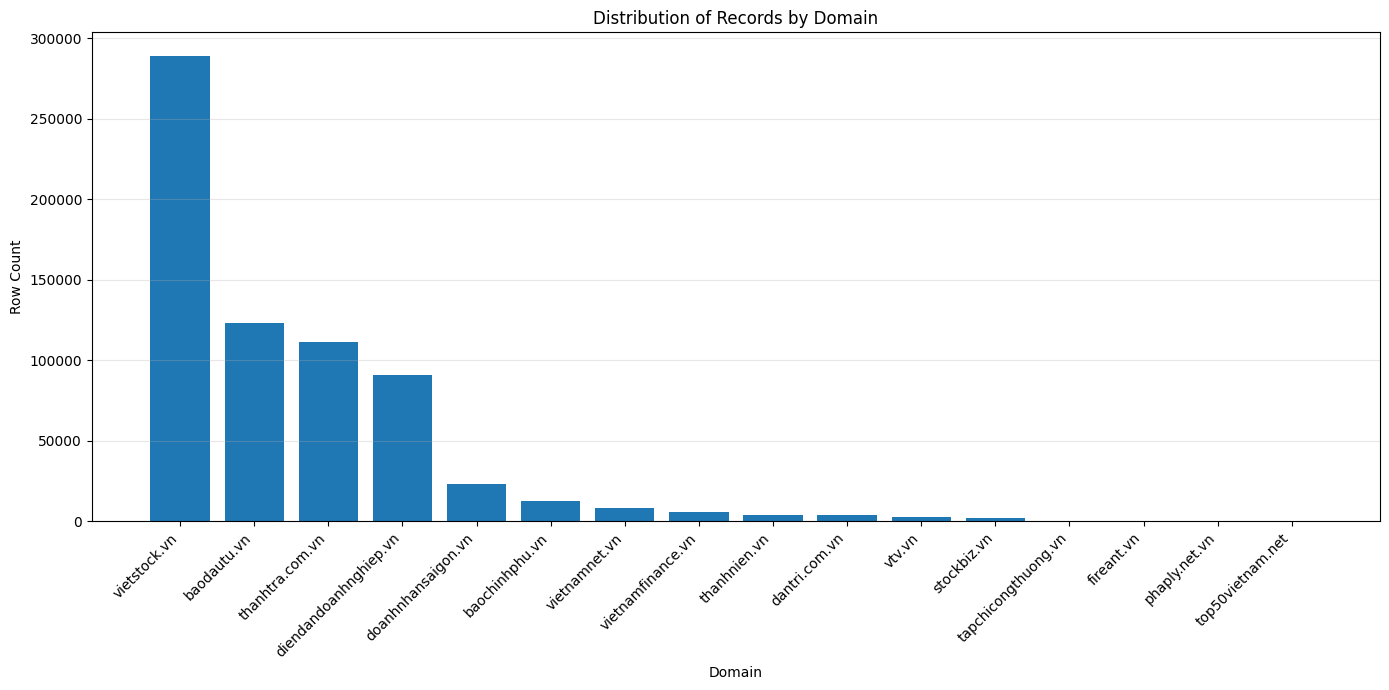

In [8]:
import matplotlib.pyplot as plt

plot_df = domain_summary.copy()

plt.figure(figsize=(14, 7))
plt.bar(plot_df["Domain"], plot_df["Row_count"])

plt.title("Distribution of Records by Domain")
plt.xlabel("Domain")
plt.ylabel("Row Count")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

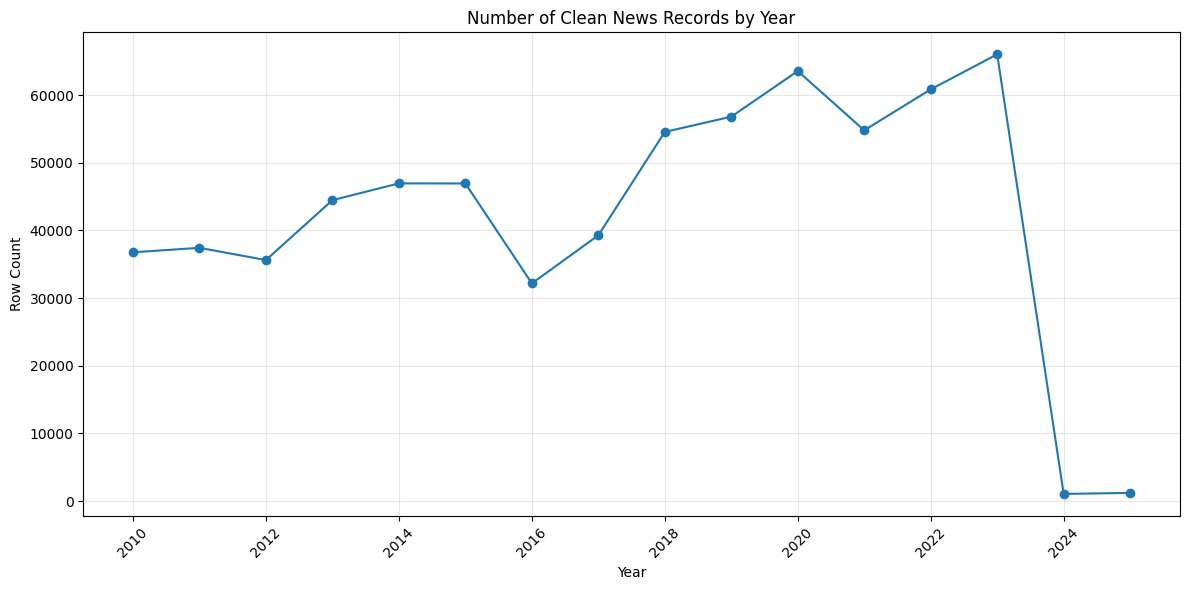

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plot_df = clean_news_df.copy()
plot_df["publication_date"] = pd.to_datetime(plot_df["publication_date"], errors="coerce")
plot_df["year"] = plot_df["publication_date"].dt.year.astype("Int64")

year_counts = (
    plot_df.loc[plot_df["year"].notna()]
    .groupby("year")
    .size()
    .reset_index(name="row_count")
    .sort_values("year")
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 6))
plt.plot(year_counts["year"], year_counts["row_count"], marker="o")

plt.title("Number of Clean News Records by Year")
plt.xlabel("Year")
plt.ylabel("Row Count")

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(2))
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
from __future__ import annotations
from pathlib import Path
import re
from typing import Iterable
import pandas as pd
INPUT_PATH = "dataset_news.parquet"
TEXT_COLUMNS = [
    "link",
    "domain",
    "category",
    "title",
    "description",
    "keywords",
    "author",
]
NULL_LIKE_VALUES = {"", "0", "null", "nan", "none"}


def load_input_data(path: str | Path) -> pd.DataFrame:
    source_path = Path(path)
    if not source_path.exists():
        raise FileNotFoundError(f"Input file not found: {source_path}")
    elif source_path.suffix.lower() == ".parquet":
        df = pd.read_parquet(source_path)
    else:
        raise ValueError("INPUT_PATH must point to a .parquet file.")
    return df


def normalize_text_columns(df: pd.DataFrame, text_columns: Iterable[str]) -> pd.DataFrame:
    out = df.copy()
    for column in text_columns:
        out[column] = out[column].astype("string")
        out[column] = out[column].str.replace(r"[\x00-\x1F\x7F-\x9F]", " ", regex=True)
        out[column] = out[column].str.replace(r"\s+", " ", regex=True).str.strip()
    return out


def build_missing_records(df: pd.DataFrame) -> pd.DataFrame:
    records = []
    for column in df.columns:
        series = df[column]
        if column == "description":
            missing_mask = series.apply(count_words_in_text).eq(0)
        elif pd.api.types.is_string_dtype(series) or str(series.dtype) in {"object", "string"}:
            text_series = series.astype("string").str.strip()
            missing_value_mask = text_series.isna()
            null_like_mask = text_series.fillna("").str.lower().isin(NULL_LIKE_VALUES)
            missing_mask = missing_value_mask | null_like_mask

            if column == "publication_date":
                publication_date_text = text_series.fillna("")
                publication_date_text = publication_date_text.str.replace(r"\s*\(GMT[+-]\d+\)\s*$", "", regex=True)
                publication_date_digits = publication_date_text.str.replace(r"\D", "", regex=True)
                zero_publication_date_mask = (
                    publication_date_digits.ne("")
                    & publication_date_digits.str.fullmatch(r"0+", na=False)
                )
                missing_mask = missing_mask | zero_publication_date_mask
        else:
            missing_mask = series.isna()

        records.append(
            {
                "column": column,
                "number_of_missing_rows": int(missing_mask.sum()),
            }
        )
    missing_records = pd.DataFrame(records)
    return missing_records


def parse_publication_date_series(series: pd.Series) -> pd.Series:
    text_series = series.astype("string").str.strip()
    text_series = text_series.str.replace(r"\s*\(GMT[+-]\d+\)\s*$", "", regex=True)
    text_series = text_series.str.replace(r"([+-]\d{2}:?\d{2}|Z)$", "", regex=True)
    text_series = text_series.mask(text_series.str.lower().isin(NULL_LIKE_VALUES))
    text_series = text_series.mask(text_series.eq("0000-00-00 00:00:00"))
    parsed_publication_date = pd.to_datetime(
        text_series,
        errors="coerce",
        format="mixed",
        dayfirst=True,
    )
    return parsed_publication_date


def count_words_in_text(raw: object) -> int:
    if pd.isna(raw):
        return 0

    text = str(raw).strip()
    text = re.sub(r"[\x00-\x1F\x7F-\x9F]", " ", text) 

    if text == "" or text.lower() in NULL_LIKE_VALUES:
        return 0

    normalized_text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    tokens = normalized_text.split()
    word_tokens = [
        token
        for token in tokens
        if token.lower() not in NULL_LIKE_VALUES
        and re.search(r"[^\W\d_]", token, flags=re.UNICODE)
    ]
    return len(word_tokens)


def add_description_word_count(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["description_word_count"] = out["description"].apply(count_words_in_text)
    return out


def calculate_description_word_count_percentiles(df: pd.DataFrame) -> dict[str, float]:
    series = df["description_word_count"].dropna()
    if series.empty:
        return {"p50": 0.0, "p90": 0.0, "p99": 0.0, "p5": 0.0}

    return {
        "p50": round(float(series.quantile(0.50)), 2),
        "p90": round(float(series.quantile(0.90)), 2),
        "p99": round(float(series.quantile(0.99)), 2),
        "p5": round(float(series.quantile(0.05)), 2)
    }


def split_missing_description_rows(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = add_description_word_count(df)
    has_description_mask = out["description_word_count"].gt(0)
    has_description_df = out.loc[has_description_mask].copy().reset_index(drop=True)
    missing_description_df = out.loc[~has_description_mask].copy().reset_index(drop=True)
    return has_description_df, missing_description_df


def build_duplicate_link_date_rows(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.loc[df.duplicated(subset=["link", "publication_date"], keep=False)]
        .sort_values(["link", "publication_date"], kind="mergesort")
        .reset_index(drop=True)
    )


def build_year_record_counts(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
    out["publication_date"] = parse_publication_date_series(out["publication_date"])
    out["year_from_publication_date"] = out["publication_date"].dt.year.astype("Int64")
    out["analysis_year"] = out["year_from_publication_date"].where(
        out["year_from_publication_date"].notna(),
        out["year"],
    )
    year_record_counts = (
        out.loc[out["analysis_year"].notna()]
        .groupby("analysis_year", dropna=False)
        .size()
        .reset_index(name="number_of_records")
        .rename(columns={"analysis_year": "year"})
        .sort_values("year", kind="mergesort")
        .reset_index(drop=True)
    )
    return year_record_counts


def build_year_before_2010_rows(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
    out["publication_date"] = parse_publication_date_series(out["publication_date"])
    out["year_from_publication_date"] = out["publication_date"].dt.year.astype("Int64")
    analysis_year = out["year_from_publication_date"].where(
        out["year_from_publication_date"].notna(),
        out["year"],
    )
    valid_analysis_year_mask = analysis_year.notna() & analysis_year.ge(1901)
    year_before_2010_rows = out.loc[valid_analysis_year_mask & analysis_year.lt(2010)].copy()
    return year_before_2010_rows


def build_unique_value_counts(df: pd.DataFrame, column: str) -> pd.DataFrame:
    series = df[column]
    if pd.api.types.is_string_dtype(series) or str(series.dtype) in {"object", "string"}:
        text_series = series.astype("string").str.strip()
        valid_mask = ~(text_series.isna() | text_series.fillna("").str.lower().isin(NULL_LIKE_VALUES))
        value_series = text_series.loc[valid_mask]
    else:
        valid_mask = series.notna()
        value_series = series.loc[valid_mask]

    summary = (
        value_series
        .astype("string")
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="row_count")
        .sort_values(["row_count", column], ascending=[False, True], kind="mergesort")
        .reset_index(drop=True)
    )
    return summary


def build_unique_domains(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["domain"] = out["domain"].astype("string").str.strip().str.lower()
    unique_domains = build_unique_value_counts(out, "domain")[["domain"]].copy()
    return unique_domains


def build_unique_categories(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["category"] = out["category"].astype("string").str.strip().str.lower()
    unique_categories = build_unique_value_counts(out, "category")[["category"]].copy()
    return unique_categories


def build_domain_record_counts(df: pd.DataFrame) -> pd.DataFrame:
    domain_series = df["domain"].astype("string").str.strip().str.lower()
    valid_domain_mask = ~(domain_series.isna() | domain_series.fillna("").isin(NULL_LIKE_VALUES))
    domain_record_counts = (
        domain_series.loc[valid_domain_mask]
        .value_counts(dropna=False)
        .rename_axis("domain")
        .reset_index(name="number_of_records")
        .sort_values(["number_of_records", "domain"], ascending=[False, True], kind="mergesort")
        .reset_index(drop=True)
    )
    return domain_record_counts


def main() -> None:
    raw_df = load_input_data(INPUT_PATH)
    normal_text = normalize_text_columns(raw_df, TEXT_COLUMNS)
    parsed_publication_date = parse_publication_date_series(normal_text["publication_date"])
    has_description_df, missing_description_df = split_missing_description_rows(normal_text)
    missing_records = build_missing_records(normal_text)
    duplicate_rows = build_duplicate_link_date_rows(normal_text)
    year_record_counts = build_year_record_counts(normal_text)
    unique_domains = build_unique_domains(normal_text)
    description_word_count_percentiles = calculate_description_word_count_percentiles(has_description_df)
    build_domain_record_counts_df = build_domain_record_counts(normal_text)
    unique_categories = build_unique_categories(normal_text)
    year_before_2010_rows = build_year_before_2010_rows(normal_text)


    print("Input records:", len(raw_df))
    print("Unique domains:", len(unique_domains))
    print("Duplicate rows by link + publication_date:", len(duplicate_rows))
    print("Unique categories:", len(unique_categories))
    if parsed_publication_date.notna().any():
        print("Min publication date:", parsed_publication_date.min().strftime("%Y-%m-%d %H:%M:%S.0"))
        print("Max publication date:", parsed_publication_date.max().strftime("%Y-%m-%d %H:%M:%S.0"))
    else:
        print("Min publication date:", pd.NA)
        print("Max publication date:", pd.NA)
    print("Rows with year < 2010:", len(year_before_2010_rows))
    print(f"Maximum description word count: {has_description_df['description_word_count'].max()}")
    print(f"Minimum description word count: {has_description_df['description_word_count'].min()}")
    print(f"Average description word count: {has_description_df['description_word_count'].mean():.2f}")
    print(f"Description word count p50: {description_word_count_percentiles['p50']}")
    print(f"Description word count p90: {description_word_count_percentiles['p90']}")
    print(f"Description word count p99: {description_word_count_percentiles['p99']}")
    print(f"Description word count p5: {description_word_count_percentiles['p5']}")
    
    for _, row in year_record_counts.iterrows():
        print(f"number of records in year {int(row['year'])}: {row['number_of_records']}")

    for _, row in missing_records.iterrows():
        print(f"number of missing rows in {row['column']}: {row['number_of_missing_rows']}")

    for _, row in build_domain_record_counts_df.iterrows():
        print(f"number of records per domain: {row['domain']} - {row['number_of_records']}")

if __name__ == "__main__":
    main()


FileNotFoundError: Input file not found: dataset_news.parquet

In [ ]:
from __future__ import annotations
import ast
import pandas as pd

try:
    from News.EDA_clean.EDA_raw_news import add_description_word_count
    from News.EDA_clean.EDA_raw_news import build_year_before_2010_rows
    from News.EDA_clean.EDA_raw_news import INPUT_PATH
    from News.EDA_clean.EDA_raw_news import load_input_data
    from News.EDA_clean.EDA_raw_news import NULL_LIKE_VALUES
    from News.EDA_clean.EDA_raw_news import normalize_text_columns
    from News.EDA_clean.EDA_raw_news import parse_publication_date_series
    from News.EDA_clean.EDA_raw_news import TEXT_COLUMNS
except ImportError:
    from News.EDA_clean.EDA_raw_news import add_description_word_count
    from News.EDA_clean.EDA_raw_news import build_year_before_2010_rows
    from News.EDA_clean.EDA_raw_news import INPUT_PATH
    from News.EDA_clean.EDA_raw_news import load_input_data
    from News.EDA_clean.EDA_raw_news import NULL_LIKE_VALUES
    from News.EDA_clean.EDA_raw_news import normalize_text_columns
    from News.EDA_clean.EDA_raw_news import parse_publication_date_series
    from News.EDA_clean.EDA_raw_news import TEXT_COLUMNS


def normalize_domain_column(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = df.copy()
    normalize_domain = out.copy()
    domain = normalize_domain["domain"].astype("string").str.lower()
    domain = domain.mask(domain.isna() | domain.fillna("").isin(NULL_LIKE_VALUES))
    domain = domain.str.replace(r"^https?://", "", regex=True)
    domain = domain.str.replace(r"^www\.", "", regex=True)
    domain = domain.str.split("/", n=1).str[0]
    domain = domain.str.split("?", n=1).str[0]
    domain = domain.str.split("#", n=1).str[0]
    normalize_domain["domain"] = domain.mask(domain.fillna("").eq("")).astype("string")
    return out, normalize_domain


def parse_dict_like_keywords(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = df.copy()
    original_keywords = out["keywords"].astype("string")

    def parse_keyword_value(raw: object) -> object:
        if pd.isna(raw):
            return pd.NA

        if isinstance(raw, dict):
            keys = [str(key) for key in raw.keys() if str(key) != ""]
            return ", ".join(keys) if keys else pd.NA

        text = str(raw)
        if text == "" or text.lower() in NULL_LIKE_VALUES:
            return pd.NA
        if not (text.startswith("{") and text.endswith("}")):
            return text

        try:
            parsed = ast.literal_eval(text)
        except Exception:
            return text

        if isinstance(parsed, dict):
            keys = [str(key) for key in parsed.keys() if str(key) != ""]
            return ", ".join(keys) if keys else pd.NA
        return text

    out["keywords"] = out["keywords"].apply(parse_keyword_value).astype("string")
    parsed_mask = original_keywords.ne(out["keywords"].astype("string"))
    parsed_keyword_rows = out.loc[parsed_mask].copy().reset_index(drop=True)
    return out, parsed_keyword_rows


def build_clean_news(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    raw_publication_date = out["publication_date"].astype("string").str.strip()
    raw_publication_date = raw_publication_date.str.replace(r"\s*\(GMT[+-]\d+\)\s*$", "", regex=True)
    publication_date_digits = raw_publication_date.fillna("").str.replace(r"\D", "", regex=True)
    zero_publication_date_mask = (
        publication_date_digits.ne("")
        & publication_date_digits.str.fullmatch(r"0+", na=False)
    )
    invalid_publication_date_mask = (
        raw_publication_date.isna()
        | raw_publication_date.fillna("").str.lower().isin(NULL_LIKE_VALUES)
        | zero_publication_date_mask
    )
    out["publication_date"] = parse_publication_date_series(out["publication_date"])
    out = out.loc[~invalid_publication_date_mask & out["publication_date"].notna()].copy()
    year_before_2010_rows = build_year_before_2010_rows(out)
    out = out.drop(index=year_before_2010_rows.index).copy()
    out = add_description_word_count(out)
    out = out.loc[out["description_word_count"].ge(5)].copy()
    out = out.drop_duplicates(subset=["link", "publication_date"], keep="first").copy()
    out = out.sort_values(["publication_date", "link"], kind="mergesort").reset_index(drop=True)

    _, normalize_domain = normalize_domain_column(out)
    normalized_keywords, parsed_keyword_rows = parse_dict_like_keywords(out)

    clean_news = pd.DataFrame(
        {
            "publication_date": out["publication_date"],
            "year": out["year"],
            "domain_norm": normalize_domain["domain"].astype("string"),
            "category": out["category"],
            "title": out["title"],
            "description": out["description"],
            "keywords_norm": normalized_keywords["keywords"].astype("string"),
        }
    )
    return clean_news.reset_index(drop=True)


def main() -> None:
    raw_df = load_input_data(INPUT_PATH)
    normalized_df = normalize_text_columns(raw_df, TEXT_COLUMNS)
    input_rows = len(raw_df)
    clean_news_df = build_clean_news(normalized_df)

    print("Input rows:", input_rows)
    print("Clean news rows:", len(clean_news_df))

if __name__ == "__main__":
    main()


Input rows: 719603
Clean news rows: 678418


In [ ]:
raw_df = load_input_data(INPUT_PATH)
normalized_df = normalize_text_columns(raw_df, TEXT_COLUMNS)
input_rows = len(raw_df)
clean_news_df = build_clean_news(normalized_df)
df = clean_news_df.copy()
# df.to_parquet("clean_news.parquet", index=False)
# df.to_csv("clean_news.csv", index=False)
df["keywords_norm"].head()

KeyError: 'keywwords_norm'

In [6]:
df_norm = pd.read_parquet("clean_news.parquet")
df_norm["keywords_norm"].to_csv("keywords_norm.csv", index=False)

In [10]:
df_cate = pd.read_parquet("clean_news.parquet")
df_cate[["category"]].drop_duplicates().to_csv("category.csv", index=False)

In [12]:
df_cate.columns

Index(['publication_date', 'year', 'domain_norm', 'category', 'title',
       'description', 'keywords_norm'],
      dtype='object')

In [17]:
import pandas as pd

equity_df = pd.read_csv("equity.csv")

# 2. Lấy danh sách category equity
equity_categories = (
    equity_df["category"]
    .astype("string")
    .str.strip()
    .str.strip('"')
    .str.lower()
)

# 3. Chuẩn hóa category trong clean_news_df
df = clean_news_df.copy()
df["category"] = (
    df["category"]
    .astype("string")
    .str.strip()
    .str.strip('"')
    .str.lower()
)

# 4. Lọc các record có category nằm trong equity.csv
equity_news_df = df.loc[df["category"].isin(equity_categories)].copy()

print("Input rows:", len(df))
print("Number of equity categories:", len(equity_categories))
print("Equity rows:", len(equity_news_df))

equity_news_df.head()

Input rows: 678418
Number of equity categories: 21
Equity rows: 147509


,publication_date,year,domain_norm,category,title,description,keywords_norm
15,2010-01-01 18:15:00,2010,vietstock.vn,<NA>,Dự cảm thị trường chứng khoán năm 2010,Năm 2010 được các chuyên gia đánh giá là sẽ có...,<NA>
16,2010-01-01 18:21:00,2010,vietstock.vn,<NA>,“TTCK 2010 sẽ sớm hồi phục và tiếp tục là kênh...,Một trong những biến động lớn nhất của thị trư...,<NA>
20,2010-01-01 19:00:00,2010,vietstock.vn,<NA>,Thị trường bất động sản 2010: Thống nhất một mối,Đó là sự khẳng định của một số DN- chuyên gia ...,<NA>
22,2010-01-01 19:19:00,2010,vietstock.vn,<NA>,Thị trường chứng khoán: Hành trang vào năm 2010,"Năm 2009 đã khép lại cùng với những buồn, vui ...",<NA>
23,2010-01-01 19:23:00,2010,vietstock.vn,giao dịch nội bộ,Cổ đông nội bộ AGF và BVH vi phạm CBTT,(Vietstock) - Sở GDCK TPHCM (HOSE) thông báo v...,<NA>


In [ ]:
equity_news_df.to_csv("equity_news.csv", index=False)

In [ ]:
df = equity_news_df.copy()
df["des-title"] = df["title"].astype(str) + " " + df["description"].astype(str)
df = df.drop(columns=["title", "description","year"])
df.to_csv("equity_news_des_title.csv", index=False)

In [28]:
df1 = df.copy()
df1 = df1[~df1["category"].isna() & df1["category"].str.strip().ne("")]
df1.to_parquet("equity_news_des_title.parquet", index=False)

In [ ]:
from pathlib import Path
import pandas as pd
from underthesea import word_tokenize


INPUT_PATH = Path.cwd() / ("equity_news_des_title.parquet")
TEXT_COLUMN = "des-title"
TOKENIZED_COLUMN = "Tokenize_des"


def tokenize_vietnamese_text(text: object) -> str:
    if pd.isna(text):
        return ""
    return word_tokenize(str(text), format="text")


def load_and_tokenize_equity_news(path: Path = INPUT_PATH) -> pd.DataFrame:
    df = pd.read_parquet(path)

    out = df.copy()
    out[TOKENIZED_COLUMN] = out[TEXT_COLUMN].apply(tokenize_vietnamese_text)
    return out


def main() -> None:
    df = load_and_tokenize_equity_news()
    print(df.head())

if __name__ == "__main__":
    main()


NameError: name '__file__' is not defined

In [3]:
df = load_and_tokenize_equity_news()
df[["des-title", "Tokenize_des"]].to_csv("equity_news_tokenized.csv", index=False)

In [ ]:
from pathlib import Path
import re
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import CountVectorizer
from underthesea import word_tokenize


INPUT_PATH = Path.cwd() / ("equity_news_des_title.parquet")
TEXT_COLUMN = "des-title"
TOKENIZED_COLUMN = "Tokenize_des"
TOKEN_PATTERN = re.compile(r"[^\W\d_]", flags=re.UNICODE)
SPECIAL_CHARACTER_PATTERN = re.compile(r"[^\w\s]", flags=re.UNICODE)
WHITESPACE_PATTERN = re.compile(r"\s+", flags=re.UNICODE)


def clean_token(token: str) -> str | None:
    token = SPECIAL_CHARACTER_PATTERN.sub(" ", token.strip().lower())
    token = WHITESPACE_PATTERN.sub("_", token).strip("_")
    if len(token) <= 1:
        return None
    if not TOKEN_PATTERN.search(token):
        return None
    if token[0].isdigit():
        return None
    return token


def tokenize_vietnamese_text(text: object) -> list[str]:
    if pd.isna(text):
        return []

    tokens = word_tokenize(str(text), format=None)
    cleaned_tokens = [clean_token(token) for token in tokens]
    return [token for token in cleaned_tokens if token is not None]


def load_and_tokenize_equity_news(path: Path = INPUT_PATH) -> pd.DataFrame:
    df = pd.read_parquet(path)

    out = df.copy()
    out[TOKENIZED_COLUMN] = out[TEXT_COLUMN].apply(tokenize_vietnamese_text)
    return out


def build_term_document_matrix(df: pd.DataFrame, text_column: str = TOKENIZED_COLUMN, min_df: int = 2) -> tuple[csr_matrix, list[str], CountVectorizer]:
    vectorizer = CountVectorizer(
        analyzer=lambda tokens: tokens,
        lowercase=False,
        min_df=min_df,
        dtype="int32",
    )
    term_document_matrix = vectorizer.fit_transform(df[text_column])
    terms = vectorizer.get_feature_names_out().tolist()
    return term_document_matrix, terms, vectorizer


def main() -> None:
    df = load_and_tokenize_equity_news()
    term_doc_matrix, terms, _ = build_term_document_matrix(df)
    print("Term-document matrix shape:", term_doc_matrix.shape)
    print("First 20 terms:", terms[:20])

if __name__ == "__main__":
    main()


Term-document matrix shape: (130585, 27635)
First 20 terms: ['a2', 'a2z', 'a321', 'a321neo', 'a4', 'a7', 'a8', 'a_a', 'a_bank', 'a_billion', 'a_c', 'a_c_b', 'a_cdm', 'a_lưới', 'a_m_best', 'a_p', 'a_tp_hcm', 'a_vương', 'a_đến', 'a_đến_z']
0    [cổ_đông, nội_bộ, agf, và, bvh, vi_phạm, cbtt,...
1    [lên, phương_án, chuyển_đổi, vietsovpetro, thủ...
2    [kss, dẫn_đầu, về, vốn, hóa, ngành, khai_khoán...
3    [sec, bản_cáo, bạch_niêm_yết, lần, đầu, ctcp, ...
4    [thêm, công_ty, được, giao_dịch, trên, upcom, ...
Name: Tokenize_des, dtype: object


In [9]:
df = load_and_tokenize_equity_news()
df.to_parquet("equity_news_tokenized.parquet", index=False)

In [7]:
term_doc_matrix, terms, _ = build_term_document_matrix(df)
pd.DataFrame({"term": terms}).to_csv("all_terms.csv", index=False, encoding="utf-8-sig")

In [10]:
df = pd.read_parquet("equity_news_tokenized.parquet")
df.columns

Index(['publication_date', 'domain_norm', 'category', 'keywords_norm',
       'des-title', 'Tokenize_des', 'total_tokenizer'],
      dtype='object')

In [ ]:
from __future__ import annotations

from pathlib import Path
import math
import re
import sys

import pandas as pd

try:
    from News.Process_sentiment_label.build_CSR_matrix import INPUT_PATH
    from News.Process_sentiment_label.build_CSR_matrix import TOKENIZED_COLUMN
    from News.Process_sentiment_label.build_CSR_matrix import build_term_document_matrix
    from News.Process_sentiment_label.build_CSR_matrix import build_tf_df_dataframe
except ImportError:
    from News.Process_sentiment_label.build_CSR_matrix import INPUT_PATH
    from News.Process_sentiment_label.build_CSR_matrix import TOKENIZED_COLUMN
    from News.Process_sentiment_label.build_CSR_matrix import build_term_document_matrix
    from News.Process_sentiment_label.build_CSR_matrix import build_tf_df_dataframe


LETTER_PATTERN = re.compile(r"[^\W\d_]", flags=re.UNICODE)

VIETNAMESE_STOPWORDS = {
    "ai",
    "anh",
    "bà",
    "bài",
    "bạn",
    "bằng",
    "bị",
    "bộ",
    "bởi",
    "cả",
    "các",
    "cái",
    "cần",
    "càng",
    "chỉ",
    "cho",
    "chưa",
    "có",
    "còn",
    "cùng",
    "của",
    "cũng",
    "đã",
    "đang",
    "đây",
    "đến",
    "để",
    "đều",
    "điều",
    "đó",
    "được",
    "gì",
    "hơn",
    "khi",
    "không",
    "là",
    "lại",
    "lên",
    "mà",
    "một",
    "một_số",
    "này",
    "năm",
    "nếu",
    "ngày",
    "nhiều",
    "những",
    "sẽ",
    "sự",
    "số",
    "sở",
    "sau",
    "theo",
    "thì",
    "thông_qua",
    "tại",
    "từ",
    "trong",
    "trên",
    "trước",
    "và",
    "vào",
    "về",
    "vì",
    "việc",
    "với",
}


def add_term_statistics(tf_df: pd.DataFrame, total_documents: int) -> pd.DataFrame:
    out = tf_df.copy()
    out["df_ratio"] = out["df"] / total_documents
    out["avg_tf_per_doc"] = out["tf"] / out["df"]
    out["candidate_score"] = out["tf"] * out["df"].apply(
        lambda df: math.log((total_documents + 1) / (df + 1))
    )
    return out


def check_term_valid(term: str) -> str | None:
    if not isinstance(term, str):
        return "invalid_shape"
    if len(term) <= 1:
        return "invalid_shape"
    if not LETTER_PATTERN.search(term):
        return "invalid_shape"
    if any(character.isdigit() for character in term):
        return "has_digit"
    if term in VIETNAMESE_STOPWORDS:
        return "stopword"
    return None


def choose_candidate_terms(
    tf_df: pd.DataFrame,
    total_documents: int,
    min_df_ratio: float = 0.02,
    max_df_ratio: float = 0.50,
    return_groups: bool = False,
) -> pd.DataFrame | dict[str, pd.DataFrame]:
    term_stats = add_term_statistics(tf_df, total_documents)
    term_stats["rejection_reason"] = term_stats["term"].apply(check_term_valid)

    digit_mask = term_stats["rejection_reason"].eq("has_digit")
    no_digit_df, terms_with_digits_df = split_by_mask(term_stats, digit_mask)

    invalid_shape_mask = no_digit_df["rejection_reason"].eq("invalid_shape")
    valid_shape_df, invalid_shape_df = split_by_mask(no_digit_df, invalid_shape_mask)

    stopword_mask = valid_shape_df["rejection_reason"].eq("stopword")
    non_stopword_df, stopword_terms_df = split_by_mask(valid_shape_df, stopword_mask)

    below_min_df_ratio_mask = non_stopword_df["df_ratio"].lt(min_df_ratio)
    df_ratio_pass_df, below_min_df_ratio_df = split_by_mask(
        non_stopword_df,
        below_min_df_ratio_mask,
    )

    above_max_df_ratio_mask = df_ratio_pass_df["df_ratio"].gt(max_df_ratio)
    candidate_terms_df, above_max_df_ratio_df = split_by_mask(
        df_ratio_pass_df,
        above_max_df_ratio_mask,
    )

    candidate_terms_df = candidate_terms_df.drop(columns=["rejection_reason"])
    
    candidate_terms_df = candidate_terms_df.sort_values(
        by=["candidate_score", "tf", "df", "term"],
        ascending=[False, False, False, True],
        kind="mergesort",
    )
    candidate_terms_df = candidate_terms_df.reset_index(drop=True)

    if not return_groups:
        return candidate_terms_df

    return {
        "all_terms_df": term_stats.reset_index(drop=True),
        "terms_with_digits_df": terms_with_digits_df,
        "invalid_shape_df": invalid_shape_df,
        "stopword_terms_df": stopword_terms_df,
        "below_min_df_ratio_df": below_min_df_ratio_df,
        "above_max_df_ratio_df": above_max_df_ratio_df,
        "candidate_terms_df": candidate_terms_df,
    }


def split_by_mask(df: pd.DataFrame, mask: pd.Series) -> tuple[pd.DataFrame, pd.DataFrame]:
    failed_df = df.loc[mask].copy().reset_index(drop=True)
    passed_df = df.loc[~mask].copy().reset_index(drop=True)
    return passed_df, failed_df


def build_candidate_terms(
    path: Path = INPUT_PATH,
    text_column: str = TOKENIZED_COLUMN,
    vectorizer_min_df: int = 2,
    min_df_ratio: float = 0.02,
    max_df_ratio: float = 0.50,
) -> dict[str, pd.DataFrame]:
    term_document_matrix, terms, _ = build_term_document_matrix(path=path, text_column=text_column, min_df=vectorizer_min_df)
    total_documents = term_document_matrix.shape[0]
    tf_df = build_tf_df_dataframe(term_document_matrix, terms)
    return choose_candidate_terms(
        tf_df=tf_df,
        total_documents=total_documents,
        min_df_ratio=min_df_ratio,
        max_df_ratio=max_df_ratio,
        return_groups=True,
    )


def main() -> None:
    if hasattr(sys.stdout, "reconfigure"):
        sys.stdout.reconfigure(encoding="utf-8")

    result = build_candidate_terms()
    candidate_terms_df = result["candidate_terms_df"]

    print("Terms removed because they contain digits:", len(result["terms_with_digits_df"]))
    print("Terms removed because shape is invalid:", len(result["invalid_shape_df"]))
    print("Terms removed because they are stopwords:", len(result["stopword_terms_df"]))
    print("Terms removed because df_ratio < min_df_ratio:", len(result["below_min_df_ratio_df"]))
    print("Terms removed because df_ratio > max_df_ratio:", len(result["above_max_df_ratio_df"]))
    print("Candidate terms:", len(candidate_terms_df))
    print(candidate_terms_df.head(30).to_string(index=False))


if __name__ == "__main__":
    main()


Terms removed because they contain digits: 735
Terms removed because shape is invalid: 0
Terms removed because they are stopwords: 66
Terms removed because df_ratio < min_df_ratio: 26661
Terms removed because df_ratio > max_df_ratio: 0
Candidate terms: 173
        term    tf    df  df_ratio  avg_tf_per_doc  candidate_score
        đồng 67654 36424  0.278929        1.857402     86379.048255
          tỷ 60802 31726  0.242953        1.916472     86026.558506
    cổ_phiếu 43001 28028  0.214634        1.534216     66169.608770
          cp 33856 21572  0.165195        1.569442     60960.757461
       triệu 34258 22732  0.174078        1.507039     59890.328923
         mua 30030 18205  0.139411        1.649547     59167.532528
     đăng_ký 29639 20056  0.153586        1.477812     55527.296987
         bán 27151 17100  0.130949        1.587778     55195.134106
   giao_dịch 30209 21790  0.166864        1.386370     54090.271000
        tăng 29136 20826  0.159482        1.399020     53487.33

In [9]:
result = build_candidate_terms()
candidate_terms_df = result["candidate_terms_df"]
below_min_df_ratio_df = result["below_min_df_ratio_df"]
candidate_terms_df["term"].to_csv("candidate_terms.csv", index=False, encoding="utf-8-sig")
below_min_df_ratio_df["term"].to_csv("below_min_df_ratio_terms.csv", index=False, encoding="utf-8-sig")

In [3]:
import pandas as pd
df = pd.read_parquet("clean_news.parquet")
df.columns

Index(['publication_date', 'year', 'domain_norm', 'category', 'title',
       'description', 'keywords_norm'],
      dtype='object')

In [2]:
df = pd.read_parquet("equity_news_tokenized.parquet")
df["category"].drop_duplicates().to_csv("categories.csv", index=False, encoding="utf-8-sig") 

NameError: name 'pd' is not defined

In [13]:
df = pd.read_parquet("clean_news_classified_content.parquet")
df.columns


Index(['link', 'publication_date', 'domain_norm', 'category', 'title',
       'description', 'keywords_norm', 'content', 'content_length'],
      dtype='object')

In [4]:
df = pd.read_parquet("clean_news_tokenized.parquet")
df.to_csv("clean_news_tokenized.csv", index=False, encoding="utf-8-sig")
df.iloc[115001:120001].to_csv("clean_news_tokenized_sample_115000_120000.csv", index=False, encoding="utf-8-sig")

In [21]:
df = pd.read_parquet("clean_news.parquet")
df["category"].drop_duplicates().to_csv("categories1.csv", index=False, encoding="utf-8-sig")

In [22]:
categories1 = pd.read_csv("categories1.csv", dtype=str)
categories = pd.read_csv("categories.csv", dtype=str)

categories1_series = (
    categories1.iloc[:, 0]
    .astype("string")
    .str.strip()
    .str.lower()
    .dropna()
    .drop_duplicates()
)

categories_series = (
    categories.iloc[:, 0]
    .astype("string")
    .str.strip()
    .str.lower()
    .dropna()
    .drop_duplicates()
)

exclusive_categories = categories1_series.loc[~categories1_series.isin(categories_series)].reset_index(drop=True)
exclusive_categories.to_frame("category").to_csv("categories1_exclusive.csv", index=False, encoding="utf-8-sig")

In [26]:
df = pd.read_parquet("clean_news.parquet")
df.to_csv("clean_news.csv", index=False, encoding="utf-8-sig")

In [27]:
exclusive_categories = (
    pd.read_csv("categories1_exclusive.csv", dtype=str)
      .iloc[:, 0]
      .astype("string")
      .str.strip()
      .str.lower()
      .dropna()
      .drop_duplicates()
)

clean_news_df = pd.read_parquet("clean_news.parquet")

filtered_df = clean_news_df.loc[
    clean_news_df["category"]
      .astype("string")
      .str.strip()
      .str.lower()
      .isin(exclusive_categories)
].copy()

filtered_df

,publication_date,year,domain_norm,category,title,description,keywords_norm
0,2010-01-01 00:34:00,2010,vietstock.vn,Vàng và kim loại quý,Ðóng cửa sàn vàng để dồn sức cho kinh doanh thực,"Tiến sĩ Võ Trí Thành, Phó Viện trưởng Viện Ngh...",<NA>
1,2010-01-01 00:47:00,2010,vietstock.vn,Tài chính quốc tế,Kinh tế thế giới năm 2010: Phục hồi hay trì trệ?,Quỹ Tiền tệ quốc tế nhận định kinh tế thế giới...,<NA>
2,2010-01-01 00:54:00,2010,vietstock.vn,Tài chính quốc tế,FDI sẽ chỉ thực sự bứt phá vào 2010,Hội nghị Liên hợp quốc về Thương mại và Phát t...,<NA>
3,2010-01-01 01:03:00,2010,vietstock.vn,Kinh tế - Đầu tư,Năm 2010: Nhiều mặt hàng sẽ tăng giá,"Giá điện, nước sạch sinh hoạt, giá than… sẽ lê...",<NA>
4,2010-01-01 01:10:00,2010,vietstock.vn,Vĩ mô,2010: Chỉ tiêu và dự báo kinh tế và xã hội,"Cùng với nhiều khó khăn, thách thức, năm 2010 ...",<NA>
...,...,...,...,...,...,...,...
678413,2025-03-14 10:02:00,2014,vietnamfinance.vn,/bat-dong-san/,"Hưng Yên: Đấu giá tiếp 206 lô đất, khởi điểm c...","Hưng Yên: Đấu giá tiếp 206 lô đất, khởi điểm c...",<NA>
678414,2025-03-14 10:02:00,2014,vietnamfinance.vn,/bat-dong-san/,Nam Định chọn Phục Hưng Holdings làm khu NƠXH ...,Nam Định chọn Phục Hưng Holdings làm khu NƠXH ...,<NA>
678415,2025-03-14 10:02:00,2014,vietnamfinance.vn,/bat-dong-san/,The Inter5 – Biểu tượng mới phía Tây Hải Phòng...,The Inter5 – Biểu tượng mới phía Tây Hải Phòng...,<NA>
678416,2025-03-14 11:36:00,2014,vietnamfinance.vn,/bat-dong-san/,Thăm The Matrix Premium trên 'đất vàng' Hà Nội...,Thăm The Matrix Premium trên 'đất vàng' Hà Nội...,<NA>


In [29]:
filtered_df[["title","description","category"]].to_csv("clean_news_exclusive_categories.csv", index=False, encoding="utf-8-sig")

In [31]:
df = pd.read_parquet("clean_news.parquet")
df.columns

Index(['publication_date', 'year', 'domain_norm', 'category', 'title',
       'description', 'keywords_norm'],
      dtype='object')